In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [11]:
#NGUYEN
n=10; #1,5,7,8,10
sigma=0.14
realization=0

#Read high resolution ANN data and model                                                                                        
#function='tanh'
#n=7;sigma=0.04;realization=1

file_data='NN_no_overfit_inter_extrapolation_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'

dhr='../../data/nns/nguyen/inter_extrapolation/' + file_data
dhr=pd.read_csv(dhr)

display(dhr)

dnhr=dhr[dhr['rep']==n]
#dnhr=dnhr[(dnhr['x1']>=-2.0) & (dnhr['x1']<=2.0)]
dnhr.set_index('Unnamed: 0', inplace=True)
dnhr.index.name = None
dnhr=dnhr.reset_index(drop=True)

display(dnhr)

,Unnamed: 0,x,y,z,rep,zmodel
0,0,-1.0000,0.0000,-3.050000,1,-2.888866
1,1,-0.9950,0.0000,-3.011651,1,-2.857402
2,2,-0.9900,0.0000,-2.973702,1,-2.826114
3,3,-0.9850,0.0000,-2.936150,1,-2.795008
4,4,-0.9800,0.0000,-2.898993,1,-2.764086
...,...,...,...,...,...,...
161595,161595,0.9975,0.9875,0.878116,10,0.942604
161596,161596,0.9975,0.9900,0.877525,10,0.942144
161597,161597,0.9975,0.9925,0.876932,10,0.941684
161598,161598,0.9975,0.9950,0.876338,10,0.941222


,x,y,z,rep,zmodel
0,0.0000,0.0000,0.000000,10,0.008374
1,0.0000,0.0025,0.000000,10,0.008239
2,0.0000,0.0050,0.000000,10,0.008106
3,0.0000,0.0075,0.000000,10,0.007973
4,0.0000,0.0100,0.000000,10,0.007841
...,...,...,...,...,...
159995,0.9975,0.9875,0.878116,10,0.942604
159996,0.9975,0.9900,0.877525,10,0.942144
159997,0.9975,0.9925,0.876932,10,0.941684
159998,0.9975,0.9950,0.876338,10,0.941222


In [12]:
#Read NN and BMS data
NPAR=10 #10, 20
steps=50000
#Read BMS trace
filename='BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_trace_'+str(steps)+'_prior_'+str(NPAR)+ '.csv'
trace=pd.read_csv('../../data/MSTraces/nguyen/' + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

file_model='NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
model_d='../../data/nns/nguyen/approximation/'+ file_model
d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)
display(dn)

#Parameters to read models

if n==10:
    VARS = ['x','y',]
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
else:
    VARS = ['x',]
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
    
x = dnhr[[c for c in VARS]].copy()
y=dnhr.z

#VARS = ['x',]
#x =dnhr[[c for c in VARS]].copy()
#y=dnhr.y


#if NPAR==10:
#    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
#elif NPAR==20:
#    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

#Minimum description length model
minrow = trace[trace.H == min(trace.H)].iloc[0]
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))


,x,y,z,rep,noise,z_noise,zmodel
0,0.0000,0.0000,0.000000,10,-0.126187,-0.126187,0.008374
1,0.0000,0.0125,0.000000,10,-0.030054,-0.030054,0.007709
2,0.0000,0.0250,0.000000,10,0.113468,0.113468,0.007062
3,0.0000,0.0375,0.000000,10,0.119094,0.119094,0.006433
4,0.0000,0.0500,0.000000,10,0.087320,0.087320,0.005821
...,...,...,...,...,...,...,...
6395,0.9875,0.9375,0.888559,10,0.195103,1.083663,0.946784
6396,0.9875,0.9500,0.885730,10,-0.036020,0.849709,0.944562
6397,0.9875,0.9625,0.882865,10,-0.074657,0.808208,0.942317
6398,0.9875,0.9750,0.879967,10,-0.109738,0.770229,0.940048


6400
4800
0.7375


,x,y,z,rep,zmodel,ybms
0,0.0000,0.0000,0.000000,10,0.008374,0.000000
1,0.0000,0.0025,0.000000,10,0.008239,0.000000
2,0.0000,0.0050,0.000000,10,0.008106,0.000000
3,0.0000,0.0075,0.000000,10,0.007973,0.000000
4,0.0000,0.0100,0.000000,10,0.007841,0.000000
...,...,...,...,...,...,...
159995,0.9975,0.9875,0.878116,10,0.942604,0.884674
159996,0.9975,0.9900,0.877525,10,0.942144,0.884401
159997,0.9975,0.9925,0.876932,10,0.941684,0.884129
159998,0.9975,0.9950,0.876338,10,0.941222,0.883856


<Figure size 1181.1x944.882 with 0 Axes>

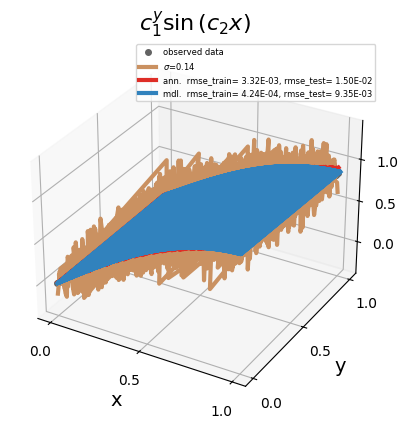

(sin((x * _a1_)) * (_a6_ ** y)) {'d0': {'_a1_': 1.5346662501405273, '_a6_': 0.8840174069591129, '_a0_': 1.0, '_a2_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a7_': 1.0}}


In [13]:
#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)

train_border=dn.loc[train_size_bms-1]['x']
print(train_size_bms)
print(train_border)

dplot = deepcopy(dnhr)
dplot['ybms'] = t.predict(x)
display(dplot)
dinterpolate=deepcopy(dplot)

#round values of x1 to two decimals to cross both dataframes
#-------------------------------------------------------------
dinterpolate=dinterpolate.round({'x':2, 'y':2})
dn=dn.round({'x':2, 'y':2})
dinterpolate=dinterpolate[-dinterpolate['x'].isin(dn['x'].tolist() )] #cross dataframes to get only high resolution points
#-------------------------------------------------------------
rmse_nn_train=root_mean_squared_error(dinterpolate.loc[:train_size_bms-1]['zmodel'],dinterpolate.loc[:train_size_bms -1]['z'])
rmse_nn_test=root_mean_squared_error(dinterpolate.loc[train_size_bms-1:]['zmodel'],dinterpolate.loc[train_size_bms -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dinterpolate.loc[:train_size_bms-1]['ybms'],dinterpolate.loc[:train_size_bms-1]['z'])
rmse_mdl_test=root_mean_squared_error(dinterpolate.loc[train_size_bms-1:]['ybms'],dinterpolate.loc[train_size_bms-1:]['z'])


 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']  
#Text and figure sizes  
#--------------------------------
size_axis=14;size_ticks=12;size_title=16
size_legend=6
line_w=3;marker_s=8
#--------------------------------

#ticks, limits and titles
#--------------------------------------------------------------------------------------------
ticks={1:{'x':[0, 0.5, 1], 'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,], 'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 

#nguyen title dict
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }
#--------------------------------------------------------------------------------------------

fig=figure(figsize=(width,height), dpi=300)    

if n==10:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(dn.x, dn.y, dn.z, '.', markersize=marker_s, color=color_data, label='observed data')
    ax.plot(dn.x, dn.y, dn.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.plot(dn.x, dn.y, dn.zmodel,linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    ax.plot(dplot.x, dplot.y, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)

else:
    plt.plot(dn['x'], dn['z'],'.', markersize=marker_s, color=color_data, label='observed data')
    plt.plot(dn['x'], dn['zmodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    plt.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    plt.plot(dn['x'], dn['z_noise'],linewidth=line_w, markersize=marker_s, color=color_noise,label=r'$\sigma$='+str(sigma)) 

    train_size=60
    train_border=dn.loc[train_size-1]['x']
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])
    

plt.legend(loc='best', fontsize=size_legend)
plt.title('$%s$' % t.latex(),fontsize=size_title)
    
Name_figure='prediction_'  + 'nguyen_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()

print(t,t.par_values)

In [ ]:
t.par_values


In [ ]:
print(len(t.par_values['d0']))

a0=t.par_values['d0']['_a0_']
a1=t.par_values['d0']['_a1_']
a2=t.par_values['d0']['_a2_']
a3=t.par_values['d0']['_a3_']
a4=t.par_values['d0']['_a4_']
a5=t.par_values['d0']['_a5_']
a6=t.par_values['d0']['_a6_']
a7=t.par_values['d0']['_a7_']
print(a1, a2, a3)
    